Step 1: Loading and getting very first look

In [58]:
import pandas as pd
import numpy as np

In [59]:
df = pd.read_csv("/content/housing.csv")

In [60]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [62]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Step 2: EDA

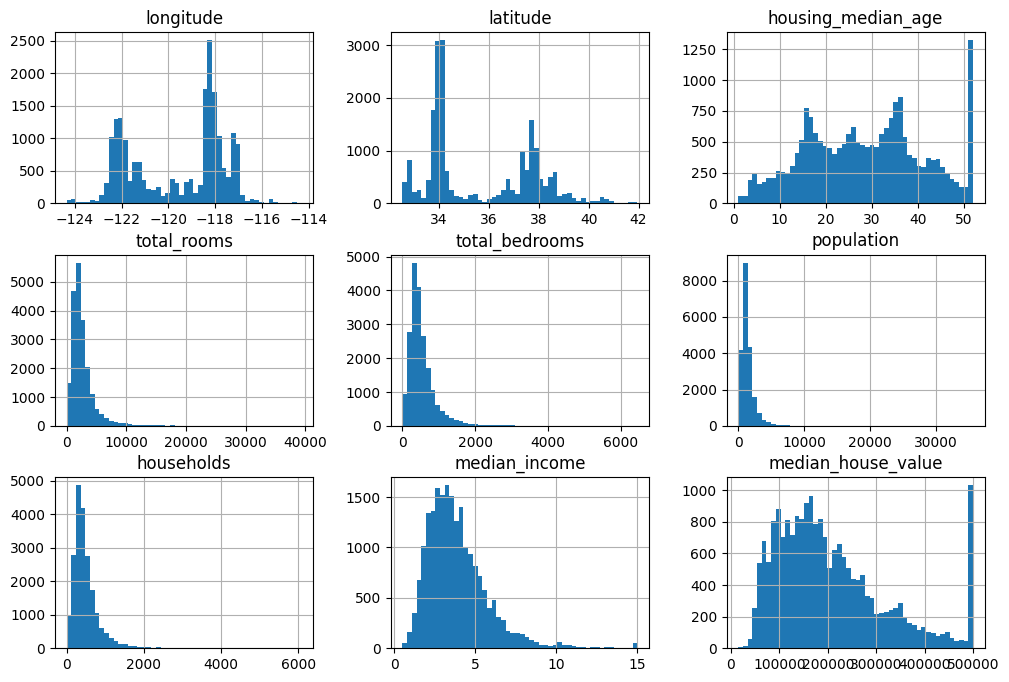

In [63]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(12, 8))
plt.show()

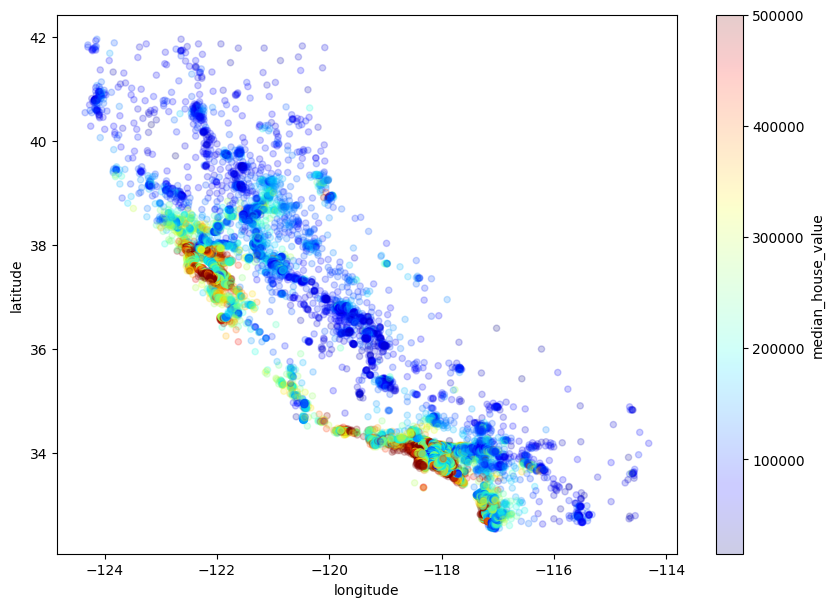

In [64]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.2,
        c="median_house_value", cmap="jet", figsize=(10,7))
plt.show()

Step 3: Why Random Splits Give Misleading Evaluations

In [65]:
df["income_cat"] = pd.cut(df["median_income"],
                           bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
                           labels=[1, 2, 3, 4, 5])

In [66]:
from sklearn.model_selection import StratifiedShuffleSplit

In [67]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in splitter.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_idx]
    strat_test_set  = df.loc[test_idx]

In [68]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

Step 4: Separate predictors from labels, and work only on a training copy

In [69]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [70]:
housing_num = housing.select_dtypes(include=[np.number])

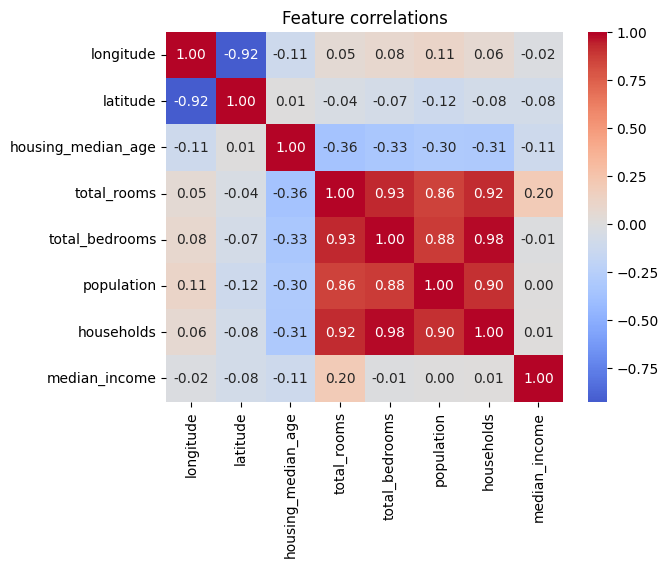

In [71]:
import seaborn as sns
corr = housing_num.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature correlations")
plt.show()

Step 5: step-by-step preprocessing is fragile

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [73]:
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

In [74]:
from sklearn.preprocessing import OneHotEncoder

In [75]:
cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

In [76]:
from sklearn.compose import ColumnTransformer

In [77]:
num_attribs = list(housing.drop("ocean_proximity", axis=1).columns)
cat_attribs = ["ocean_proximity"]

In [78]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [79]:
housing_prepared = full_pipeline.fit_transform(housing)


Step 6: Train a baseline model

In [80]:
from sklearn.linear_model import LinearRegression

In [81]:
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [82]:
predictions = lin_reg.predict(housing_prepared[:5])
print(predictions, list(housing_labels[:5]))

[ 88983.14806384 305351.35385026 153334.71183453 184302.55162102
 246840.18988841] [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


Step 7: Evaluate properly — cross-validation, not a single train score

In [83]:
from sklearn.model_selection import cross_val_score

In [84]:
scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                          scoring="neg_root_mean_squared_error", cv=10)

In [85]:
rmse_scores = -scores
print("RMSE per fold:", rmse_scores)
print("Mean:", rmse_scores.mean(), "Std:", rmse_scores.std())

RMSE per fold: [72229.03469752 65318.2240289  67706.39604745 69368.53738998
 66767.61061621 73003.75273869 70522.24414582 69440.77896541
 66930.32945876 70756.31946074]
Mean: 69204.32275494763 Std: 2372.070791055922


In [86]:
from sklearn.ensemble import RandomForestRegressor

In [87]:
forest_reg = RandomForestRegressor(random_state=42)
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                 scoring="neg_root_mean_squared_error", cv=10)

print(-forest_scores.mean())

49432.12678796127


Step 8: Final Model Fit and Test Set Evaluation

In [88]:
forest_reg.fit(housing_prepared, housing_labels)

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = full_pipeline.transform(X_test)

final_predictions = forest_reg.predict(X_test_prepared)

from sklearn.metrics import root_mean_squared_error
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

47197.66824186381


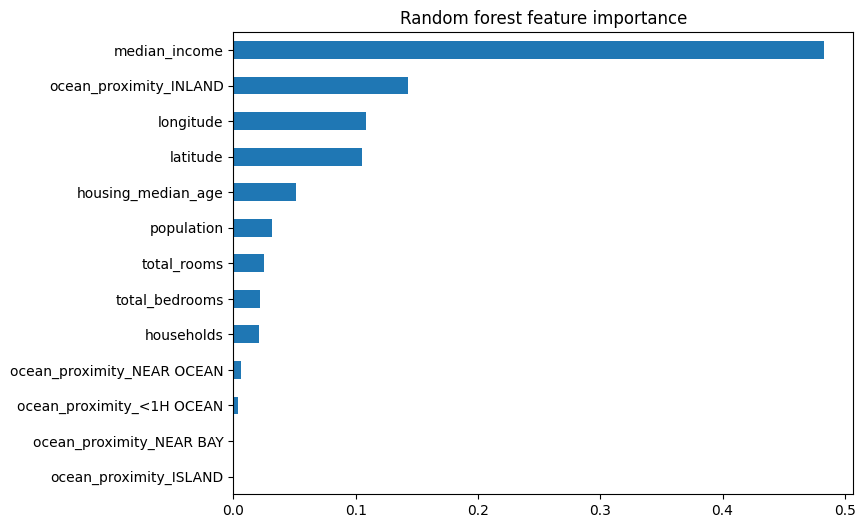

In [89]:
importances = forest_reg.feature_importances_
feature_names = num_attribs + list(full_pipeline.named_transformers_["cat"]["onehot"].get_feature_names_out())
imp_df = pd.Series(importances, index=feature_names).sort_values()
imp_df.plot(kind="barh", figsize=(8,6))
plt.title("Random forest feature importance")
plt.show()

In [90]:
import joblib

joblib.dump(full_pipeline, "pipeline.pkl")
joblib.dump(forest_reg, "model.pkl")

['model.pkl']